# **Rigid Regression From Scratch**

In [80]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from sklearn.metrics import(
    mean_squared_error,
    r2_score,
    root_mean_squared_error
)

In [81]:
class RidgeRegression:

    def __init__(self, learning_rate=0.01, epochs=1000, alpha=1.0):

        self.learning_rate = learning_rate
        self.epochs = epochs
        self.alpha = alpha

        self.weights = None
        self.bias = None

        self.loss_history = []

    def fit(self, X_train, y_train):

        n_samples, n_features = X_train.shape

        self.w = np.zeros(n_features)
        self.b = 0

        loss_history = []

        for _ in range(self.epochs):

            y_hat = self.predict(X_train)

            error = y_hat - y_train

            dw = (
                    (2 / n_samples) * (X_train.T @ error)
                    + (2 * self.alpha / n_samples) * self.w
            )

            db = (2 / n_samples) * np.sum(error)

            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            mse = np.mean(error ** 2)
            l2_penalty = (self.alpha / n_samples) * np.sum(self.w ** 2)

            loss = mse + l2_penalty

            loss_history.append(loss)

        self.loss_history = loss_history

    def predict(self, X):
        return X @ self.w + self.b


In [82]:
df_raw = load_diabetes(as_frame=True)
df = df_raw.frame

df.head(10)

X = df.drop('target' , axis = 1)
y = df['target']

X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    shuffle=True,
    random_state=42,
    test_size=0.2
)

scaler = StandardScaler(with_std=True , with_mean=True)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = RidgeRegression(
    learning_rate=0.1,
    epochs=1000,
    alpha = 0.01,
)

model.fit(X_train , y_train)

print("Weights :", model.w)
print("Bias :", model.b)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE :", rmse)
print("R² :", r2)


Weights : [  1.78980749 -11.49749159  25.73386602  16.78753962 -37.83080044
  19.4647674    4.7574019   12.22953416  32.62123912   2.39964823]
Bias : 153.7365439093484
MSE : 2895.244164483258
RMSE : 53.80747312858371
R² : 0.45353694988183757


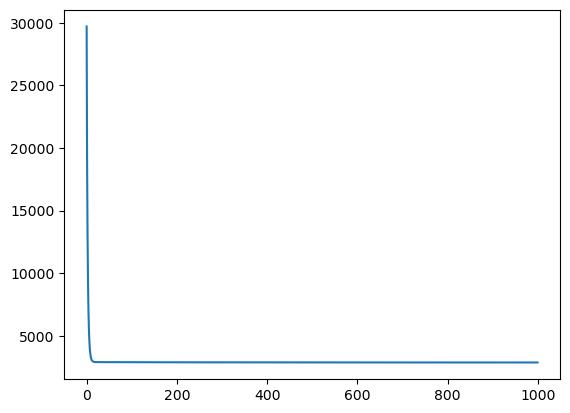

In [83]:
import matplotlib.pyplot as plt

plt.plot(range(len(model.loss_history)) , model.loss_history)
plt.show()